# Movimentaçao nos mercados de: Campeão da NFL em 2025.

**Pergunta central.**       
Como as movimentações se comportam perto da data dos jogos?   

**Hipótese**       
Após partidas com resultados dominantes (21+ Pontos de diferença) o mercado movimenta um volume maior.     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Parâmetros uteis
COR_P   = "#f07713"
COR_D = "#4cccff"
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

##Função util
def carrega(nome):
    df = pd.read_csv(nome)
    for col in df.columns:
        if df[col].dtype == object and df[col].astype(str).str.endswith("UTC").any():
            df[col] = pd.to_datetime(df[col].str.replace(" UTC", "", regex=False))
    return df

# Passo 1: Entendendo o banco de dados e seus padrões.

Buscando entender como as perguntas e os mercados são estruturados

```sql
-- Q1: como aparecem os mercados de algum time da NFL  [custo: 133,74 MB]
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%jets%'
ORDER BY volume DESC
LIMIT 30;
```

**Grão:** Cada linha de `markets` representa um mercado     
**Campos:**     
 `market_id` é o identificador do mercado     
 `question` é a pergunta negociada;     
 `event_title` agrupa mercados do mesmo evento;     
 `volume` é o total histórico negociado;    
 `created_at` e `end_date` são metadados de abertura e encerramento;    
 `closed` indica se o mercado foi fechado.  

In [2]:
q1 = carrega("dados/q1.csv")
q1[["market_id","question", "event_title", "volume", "created_at", "end_date"]].head(15)

,market_id,question,event_title,volume,created_at,end_date
0,540230,Will the New York Jets win Super Bowl 2026?,Big Game Champion 2026,5.723207e+07,2025-04-30 10:43:16 UTC,2026-02-08 12:00:00 UTC
1,506021,Will the Jets win the AFC Championship?,AFC Champion,1.854472e+07,2024-08-28 19:47:08 UTC,2025-01-26 12:00:00 UTC
2,509115,Will the Winnipeg Jets win the 2025 Stanley Cup?,Stanley Cup Champion 2025,1.346002e+07,2024-10-07 19:28:06 UTC,2025-06-23 12:00:00 UTC
3,503321,Will the Jets win Super Bowl 2025?,Super Bowl Champion 2025,1.342866e+07,2024-07-09 15:36:33 UTC,2025-02-09 12:00:00 UTC
4,672230,Jets vs. Patriots,Jets vs. Patriots,5.163531e+06,2025-11-09 06:00:01 UTC,2025-11-21 01:15:00 UTC
5,639538,Jets vs. Bengals,Jets vs. Bengals,3.421947e+06,2025-10-19 05:00:21 UTC,2025-11-02 18:00:00 UTC
6,616121,Cowboys vs. Jets,Cowboys vs. Jets,3.193943e+06,2025-09-28 05:00:18 UTC,2025-10-12 17:00:00 UTC
7,607291,Jets vs. Dolphins,Jets vs. Dolphins,2.800466e+06,2025-09-22 05:00:02 UTC,2025-10-06 23:15:00 UTC
8,632293,Panthers vs. Jets,Panthers vs. Jets,2.662480e+06,2025-10-12 05:00:30 UTC,2025-10-26 17:00:00 UTC
9,622183,Broncos vs. Jets,Broncos vs. Jets,2.349914e+06,2025-10-05 05:00:02 UTC,2025-10-19 13:30:00 UTC


O resultado demonstra 3 tipos de mercados:  
**1.Super Bowl:** `Will the Jets win Super Bowl 2025?` Duração de 7 meses   
**2.Conferência:** `Will the Jets win the AFC Championship?` Duração 150 dias/5 meses   
**3.Partidas:** `Jets vs. Patriots` Duração de 14, encerra 7 dias após o dia do jogo

**Problemas:** Os dados incluíram os Winnipeg Jets time de hockey da NHL o que pode gerar ruído  
**Possível solução:** Percebi um padrão nas janelas de duração dos mercados, os mercados de partida da NFL tem um tempo de vida de 14 dias, enquanto que os de partidas da NHL tem um tempo de vida de 28 dias.

Essa querie incluiu somente o nome "Jets", o que acontece se eu incluir o nome completo?

```sql
-- Q2: Se eu pesquisar de outra forma que outros mercados aparecem?  [custo: 133,74 MB]
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%jets%'
ORDER BY volume DESC
LIMIT 30;
```

In [3]:
q2 = carrega("dados/q2.csv")
q2[["market_id","question", "event_title", "volume", "created_at", "end_date"]].head(15)

,market_id,question,event_title,volume,created_at,end_date
0,540230,Will the New York Jets win Super Bowl 2026?,Big Game Champion 2026,5.723207e+07,2025-04-30 10:43:16 UTC,2026-02-08 12:00:00 UTC
1,1357395,Will the New York Jets win the 2027 NFL league...,NFL Champion 2027,1.225381e+06,2026-02-09 00:15:14 UTC,2027-03-31 23:55:00 UTC
2,1361083,Will New York Jets win the 2027 NFL AFC Champi...,Pro Football: 2027 AFC Champion,3.927549e+05,2026-02-09 20:54:00 UTC,2027-01-25 00:00:00 UTC
3,514544,Will the New York Jets finish with the worst r...,NFL Worst Record,2.675034e+04,2024-12-02 23:25:49 UTC,2024-12-08 12:00:00 UTC
4,540284,Will the New York Jets win the AFC East?,AFC East Winner,2.266092e+04,2025-04-30 12:05:53 UTC,2026-01-06 12:00:00 UTC
5,997484,Will the New York Jets earn the 1st pick in th...,Which team will earn the 1st pick in the 2026 ...,1.992330e+04,2025-12-22 23:48:19 UTC,2026-01-04 00:00:00 UTC
6,528654,Will Russell Wilson sign with the New York Jets?,Russell Wilson's next team?,1.981863e+04,2025-03-17 19:20:40 UTC,2025-09-03 12:00:00 UTC
7,512894,Will the New York Jets make the 2024-25 NFL Pl...,Which NFL teams will make the playoffs?,1.068713e+04,2024-11-12 19:16:21 UTC,2025-01-06 12:00:00 UTC
8,572698,Will the New York Jets finish with the worst r...,NFL Worst Team,1.047463e+04,2025-08-05 18:22:54 UTC,2026-01-10 00:00:00 UTC
9,578031,Will the New York Jets finish with the best re...,NFL Best Regular Season Team,5.774334e+03,2025-08-18 15:49:31 UTC,2026-01-10 00:00:00 UTC


**Resultados:** Aparecem outros mercados mais relacionados a especulações sobre eventos específicos do time New York Jets, mas deixam de aparecer mercados relacionados a partidas. Portanto mudar o nome não é mais efetivo para filtrar jogos somente da NFL. Usarei nome + tempo de vida para filtrar ao maximo os jogos somente pertencetes a NFL

# Passo 2: Coletar os mercados existentes relacionados ao Super Bowl com maior volume para analisá-los e comparar com as partidas.

```sql
-- Q3: Qual o mercado de maior volume relacionado ao Super Bowl [custo:133,74MB]
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%win super%' 
AND (end_date >= '2025-02-09' AND end_date < '2025-02-10') 
AND LOWER(event_title) LIKE '%champion 2025%'

ORDER BY volume DESC;
```

**Grão:** Cada linha de `markets` representa um mercado     
**Campos:**     
 `question` é a pergunta negociada;     
 `event_title` agrupa mercados do mesmo evento;     
 `volume` é o total histórico negociado;    
 `created_at` e `end_date` são metadados de abertura e encerramento;    

In [4]:
q3 = carrega("dados/q3.csv")
q3 = q3.sort_values("volume", ascending=False).reset_index(drop=True)
q3[["question", "event_title", "volume", "created_at", "end_date"]].head(15)

,question,event_title,volume,created_at,end_date
0,Will the Panthers win Super Bowl 2025?,Super Bowl Champion 2025,1.393149e+08,2024-07-09 14:59:57.000000 UTC,2025-02-09 12:00:00.000000 UTC
1,Will the Raiders win Super Bowl 2025?,Super Bowl Champion 2025,1.239699e+08,2024-07-09 15:28:42.000000 UTC,2025-02-09 12:00:00.000000 UTC
2,Will the Titans win Super Bowl 2025?,Super Bowl Champion 2025,1.195008e+08,2024-07-09 16:00:51.000000 UTC,2025-02-09 12:00:00.000000 UTC
3,Will the Browns win Super Bowl 2025?,Super Bowl Champion 2025,1.152576e+08,2024-07-09 15:04:22.000000 UTC,2025-02-09 12:00:00.000000 UTC
4,Will the Giants win Super Bowl 2025?,Super Bowl Champion 2025,1.078573e+08,2024-07-09 15:36:12.000000 UTC,2025-02-09 12:00:00.000000 UTC
5,Will the Patriots win Super Bowl 2025?,Super Bowl Champion 2025,7.427577e+07,2024-07-09 16:03:13.000000 UTC,2025-02-09 12:00:00.000000 UTC
6,Will the Falcons win Super Bowl 2025?,Super Bowl Champion 2025,4.988979e+07,2024-07-09 14:55:40.000000 UTC,2025-02-09 12:00:00.000000 UTC
7,Will the Cardinals win Super Bowl 2025?,Super Bowl Champion 2025,4.322874e+07,2024-07-09 14:51:27.000000 UTC,2025-02-09 12:00:00.000000 UTC
8,Will the Steelers win Super Bowl 2025?,Super Bowl Champion 2025,3.265106e+07,2024-07-09 15:42:19.000000 UTC,2025-02-09 12:00:00.000000 UTC
9,Will the Commanders win Super Bowl 2025?,Super Bowl Champion 2025,3.052826e+07,2024-07-09 16:01:49.000000 UTC,2025-02-09 12:00:00.000000 UTC


O mercado de maior volume está relacionado ao time Panthers, portanto irei analisar as partidas desse time para criar os alertas

# Passo 3: Escolher um jogo que teve +21 pontos de diferença envolvendo os "Panthers" e comparar com as movimentações no mercado de Super Bowl nas datas posteriores.

**Grão:** Cada linha de `dias` representa um dia    
**Campos:**     
 `trade_date` representa 1 dia;
 `daily_trade_count` é a quantidade de movimentações em 1 dia;     
 `volume_usd` é o total negociado no dia;   
 `avg_ticket` é o valor médio de cada trade realizada;  


Analisando o site da ESPN : https://www.espn.com/nfl/team/schedule/_/name/car/season/2024       
Escolhi o jogo: Carolina Panthers 10 x 36 Chicago Bears, ocorrido no dia '2024-10-06'

```sql
-- Q4a: Volume diário 7 dias antes e depois do jogo Panthers 10 x 36 Chicago [custo: 718,66 KB]

SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0) AS volume_usd
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '503301' AND (trade_date >= '2024-09-29' AND trade_date <= '2024-10-13')

ORDER BY trade_date;
```

In [5]:
q4a = carrega("dados/q4a.csv")
q4a["avg_ticket"] = q4a["volume_usd"] / q4a["daily_trade_count"]
print(q4a)

    trade_date  daily_trade_count  volume_usd  avg_ticket
0   2024-09-29                116       831.0    7.163793
1   2024-09-30                 92     32449.0  352.706522
2   2024-10-01                 84        44.0    0.523810
3   2024-10-02                156       138.0    0.884615
4   2024-10-03                 37        17.0    0.459459
5   2024-10-04                195        76.0    0.389744
6   2024-10-05                 88       145.0    1.647727
7   2024-10-06                163       133.0    0.815951
8   2024-10-07                167       477.0    2.856287
9   2024-10-08                160       235.0    1.468750
10  2024-10-09                247       645.0    2.611336
11  2024-10-10                212      1685.0    7.948113
12  2024-10-11                168        61.0    0.363095
13  2024-10-12                313      1752.0    5.597444
14  2024-10-13                387       234.0    0.604651


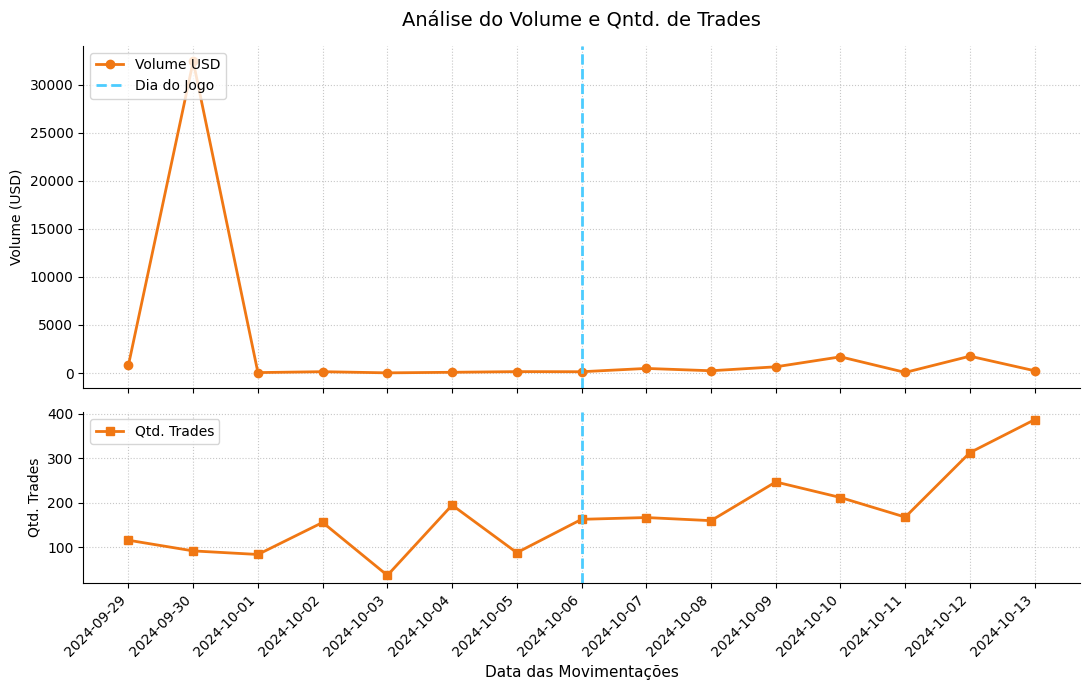

In [6]:
DIA_DO_JOGO = "2024-10-06"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, 
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(q4a['trade_date'], q4a['volume_usd'], color=COR_P, marker='o', linewidth=2, label='Volume USD')
ax1.set_title('Análise do Volume e Qntd. de Trades', fontsize=14, pad=15)
ax1.set_ylabel('Volume (USD)')

ax2.plot(q4a['trade_date'], q4a['daily_trade_count'], color=COR_P, marker='s', linewidth=2, label='Qtd. Trades')
ax2.set_xlabel('Data das Movimentações', fontsize=11)
ax2.set_ylabel('Qtd. Trades')

ax1.axvline(x=DIA_DO_JOGO, color=COR_D, linestyle='--', linewidth=2, label='Dia do Jogo')
ax2.axvline(x=DIA_DO_JOGO, color=COR_D, linestyle='--', linewidth=2)

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.grid(True, linestyle=':', alpha=0.7)
ax2.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Resultados:**     
Demonstrou um volume bem abaixo do que esperava, teve um aumento que flutua entre os dias após o jogo, mas foi movimentado um valor muito grande após uma derrota no dia '2024-09-29'. Somente com uma querie é impossível determinar se há um padrão, portanto vou verificar outra partida:
Panthers 7 x 40 Commanders dia '2024-10-20'

```sql
-- Q4b: Volume diário 7 dias antes e depois do jogo Panthers 7 x 40 Commanders [custo: 816,41 KB]

SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0) AS volume_usd
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '503301' AND (trade_date >= '2024-10-13' AND trade_date <= '2024-10-27')

ORDER BY trade_date;
```

In [7]:
q4b = carrega("dados/q4b.csv")
q4b["avg_ticket"] = q4b["volume_usd"] / q4b["daily_trade_count"]
print(q4b)

    trade_date  daily_trade_count  volume_usd  avg_ticket
0   2024-10-13                387       234.0    0.604651
1   2024-10-14                336      2374.0    7.065476
2   2024-10-15                478     12380.0   25.899582
3   2024-10-16                513      1189.0    2.317739
4   2024-10-17                700      8934.0   12.762857
5   2024-10-18                562     25006.0   44.494662
6   2024-10-19                352     24985.0   70.980114
7   2024-10-20                291     20707.0   71.158076
8   2024-10-21                541     16992.0   31.408503
9   2024-10-22                526     14062.0   26.733840
10  2024-10-23                392      6182.0   15.770408
11  2024-10-24                714      5828.0    8.162465
12  2024-10-25                412      4918.0   11.936893
13  2024-10-26                691     62543.0   90.510854
14  2024-10-27                633     48925.0   77.290679


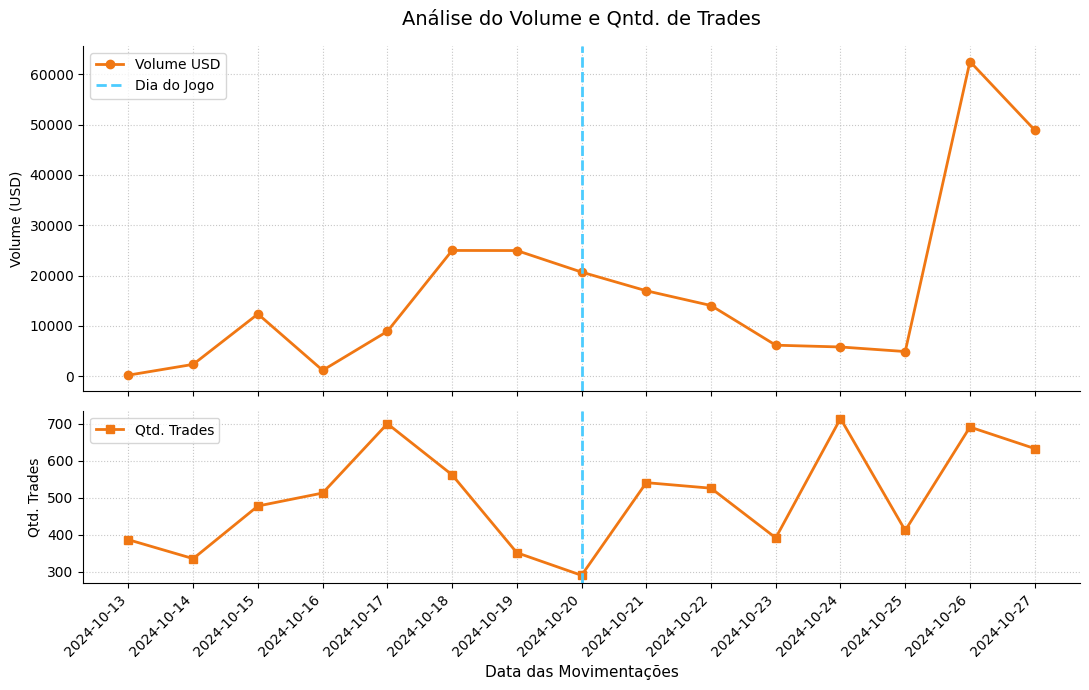

In [8]:
DIA_DO_JOGO2 = "2024-10-20"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, 
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(q4b['trade_date'], q4b['volume_usd'], color=COR_P, marker='o', linewidth=2, label='Volume USD')
ax1.set_title('Análise do Volume e Qntd. de Trades', fontsize=14, pad=15)
ax1.set_ylabel('Volume (USD)')

ax2.plot(q4b['trade_date'], q4b['daily_trade_count'], color=COR_P, marker='s', linewidth=2, label='Qtd. Trades')
ax2.set_xlabel('Data das Movimentações', fontsize=11)
ax2.set_ylabel('Qtd. Trades')

ax1.axvline(x=DIA_DO_JOGO2, color=COR_D, linestyle='--', linewidth=2, label='Dia do Jogo')
ax2.axvline(x=DIA_DO_JOGO2, color=COR_D, linestyle='--', linewidth=2)

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.grid(True, linestyle=':', alpha=0.7)
ax2.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Resultados:**     
No período dessa partida tivemos uma quantidade maior de trades e um volume maior sendo movimentado 1 dia antes e durante o dia do jogo. Percebeu-se também movimentação grande 1 dia antes do próximo jogo e no dia do próximo jogo (dias 26 e 27). Ainda esta inconclusivo, portanto vou comparar com um período em que não tiveram jogos, durante o mês de julho'

```sql
-- Q4c: Volume no mês inicial do mercado [custo: 520,81 KB KB]

SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0) AS volume_usd
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '503301' AND (trade_date >= '2024-07-09' AND trade_date <= '2024-07-31')

ORDER BY trade_date;
```

In [9]:
q4c = carrega("dados/q4c.csv")
q4c["avg_ticket"] = q4c["volume_usd"] / q4c["daily_trade_count"]  
print(q4c)

    trade_date  daily_trade_count  volume_usd  avg_ticket
0   2024-07-10                 11        22.0    2.000000
1   2024-07-11                  3         0.0    0.000000
2   2024-07-12                 31      1580.0   50.967742
3   2024-07-13                 15       437.0   29.133333
4   2024-07-14                 20      7781.0  389.050000
5   2024-07-15                 13       284.0   21.846154
6   2024-07-16                 15       395.0   26.333333
7   2024-07-17                124     15507.0  125.056452
8   2024-07-18                 32      4632.0  144.750000
9   2024-07-19                  5      4126.0  825.200000
10  2024-07-20                  6        57.0    9.500000
11  2024-07-21                 17      1316.0   77.411765
12  2024-07-22                  9        10.0    1.111111
13  2024-07-23                 15       859.0   57.266667
14  2024-07-24                 14       697.0   49.785714
15  2024-07-25                 16       491.0   30.687500
16  2024-07-26

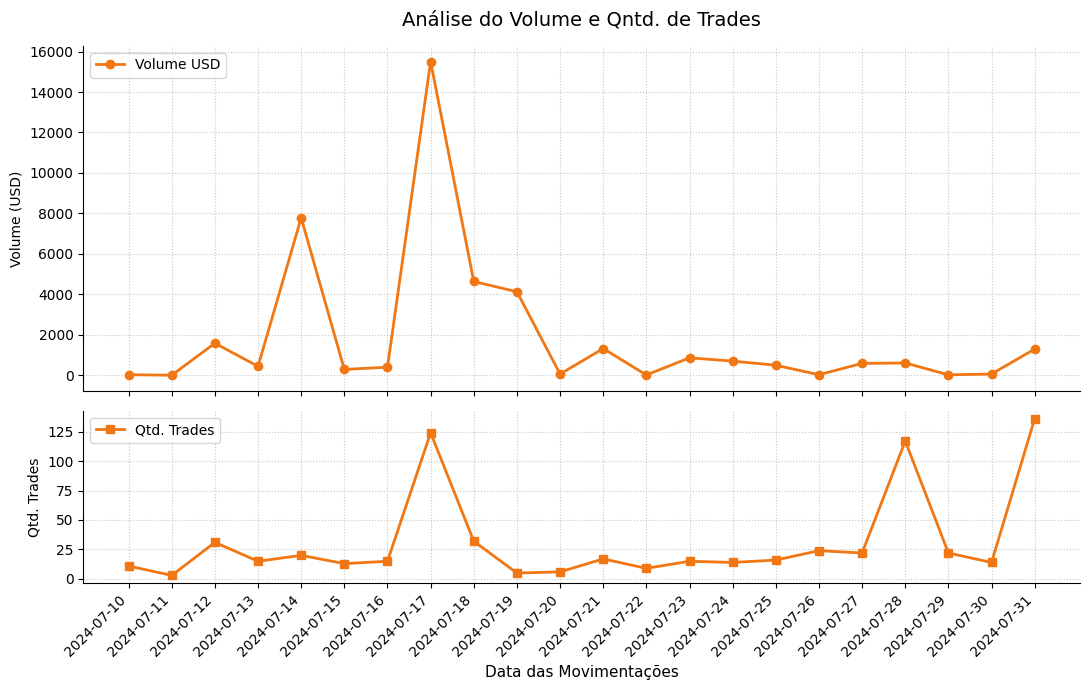

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, 
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(q4c['trade_date'], q4c['volume_usd'], color=COR_P, marker='o', linewidth=2, label='Volume USD')
ax1.set_title('Análise do Volume e Qntd. de Trades', fontsize=14, pad=15)
ax1.set_ylabel('Volume (USD)')

ax2.plot(q4c['trade_date'], q4c['daily_trade_count'], color=COR_P, marker='s', linewidth=2, label='Qtd. Trades')
ax2.set_xlabel('Data das Movimentações', fontsize=11)
ax2.set_ylabel('Qtd. Trades')

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.grid(True, linestyle=':', alpha=0.7)
ax2.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Resultado:**
O mercado aparenta sofrer uma movimentação muito maior no dia dos jogos(mais trades e maior volume) importantes e 1 dia anterior, com o resultado dos jogos não impactando na movimentação.

Por fim, vou realizar uma ultima querie de um jogo em que os Panthers venceram para confirmar a conclusão acima     
Jogo: Panthers 23 x 22 Saints Dia '2024-11-03'

```sql
-- Q4d: Volume Panthers vs Saints 4 dias antes e depois   [custo: 517,19 KB]

SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0) AS volume_usd
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '503301' AND (trade_date >= '2024-10-30' AND trade_date <= '2024-11-07')

ORDER BY trade_date;
```

In [11]:
q4d = carrega("dados/q4d.csv")
q4d["avg_ticket"] = q4d["volume_usd"] / q4d["daily_trade_count"]
print(q4d)

   trade_date  daily_trade_count  volume_usd  avg_ticket
0  2024-10-30                528      3100.0    5.871212
1  2024-10-31                522       805.0    1.542146
2  2024-11-01                313       207.0    0.661342
3  2024-11-02                168       149.0    0.886905
4  2024-11-03                323     39456.0  122.154799
5  2024-11-04                370       289.0    0.781081
6  2024-11-05                321       739.0    2.302181
7  2024-11-06                235       122.0    0.519149
8  2024-11-07                512       160.0    0.312500


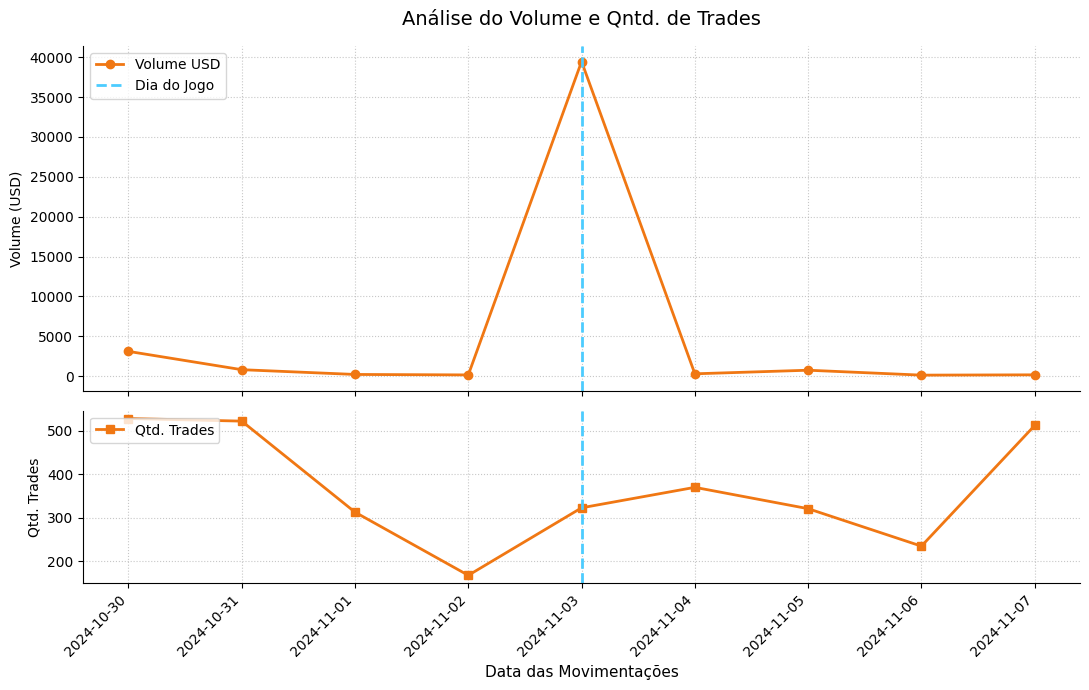

In [12]:
DIA_DO_JOGO3 = "2024-11-03"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, 
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(q4d['trade_date'], q4d['volume_usd'], color=COR_P, marker='o', linewidth=2, label='Volume USD')
ax1.set_title('Análise do Volume e Qntd. de Trades', fontsize=14, pad=15)
ax1.set_ylabel('Volume (USD)')

ax2.plot(q4d['trade_date'], q4d['daily_trade_count'], color=COR_P, marker='s', linewidth=2, label='Qtd. Trades')
ax2.set_xlabel('Data das Movimentações', fontsize=11)
ax2.set_ylabel('Qtd. Trades')

ax1.axvline(x=DIA_DO_JOGO3, color=COR_D, linestyle='--', linewidth=2, label='Dia do Jogo')
ax2.axvline(x=DIA_DO_JOGO3, color=COR_D, linestyle='--', linewidth=2)

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.grid(True, linestyle=':', alpha=0.7)
ax2.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### **Resultados gerais**
Derrotas ou vitórias não parecem gerar movimentações expressivas no mercado. As movimentações aparentam acontecer no dia de jogos mais importantes ou no dia anterior.

# Passo 4: Construção dos alertas e teste nos outros mercados.
Os dados sugeriram que os mercados recebem um volume maior de dólares nos dias das partidas importantes.
Portanto, vou construir um alerta que baseado em movimentações anormais, busca, se existe, um mercado sobre os jogos naquela data.      

Nesta parte usei as ideias para filtrar o máximo possível, limitando o tempo de vida a 14, 13 ou 12 dias, os nomes somente aos times da NFL, filtrei as trades para acima de 100, pois estavam atigindo facilmente 300 no pico e no mês vazio não passou de 150.
O volume diário como 20000, os jogos estavam demonstrando base de 25000 e avg_ticket maior que 35 para ajudar a evitar whales(investimentos massivos de poucas pessoas).

```sql
--Q5 Quais mercados relacionados a jogos existem referentes a NFL nos dias das variações [custo: 234,12 MB]
WITH dias_com_volume AS (
  SELECT DISTINCT trade_date
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  -- Mercados Super Bowl 2025
  WHERE market_id IN (
      '503301', '503314', '503327', '503304', '503320', '503329', 
      '503298', '503297', '503323', '503328', '503311', '503312', 
      '503317', '503325', '503313', '503303', '503306', '503315', 
      '503321', '503305', '503307', '503322', '503324', '503319', 
      '503316', '503300', '503302', '503309', '503326', '503318', 
      '503299'
    )
    AND daily_trade_count > 150 
    AND daily_usd_volume > 20000 
    AND SAFE_DIVIDE(daily_usd_volume, daily_trade_count) > 35
)

SELECT 
  m.market_id,
  m.question,
  m.event_title,
  DATE(m.created_at) AS data_criacao,
  DATE(m.end_date) AS data_termino,
  DATE_DIFF(DATE(m.end_date), DATE(m.created_at), DAY) AS tempo_de_vida_dias,
  dcv.trade_date AS data_do_alerta
FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
JOIN dias_com_volume dcv 
  ON DATE(m.end_date) = DATE_ADD(dcv.trade_date, INTERVAL 7 DAY) -- Os mercados de jogos terminam 7 dias após o jogo.
WHERE m.question LIKE '%vs.%'
  -- Filtro de times da NFL (Feito com IA)
  AND REGEXP_CONTAINS(
    LOWER(m.question), 
    r'\b(49ers|bears|bengals|bills|broncos|browns|buccaneers|cardinals|chargers|chiefs|colts|commanders|cowboys|dolphins|eagles|falcons|giants|jaguars|jets|lions|packers|panthers|patriots|raiders|rams|ravens|saints|seahawks|steelers|texans|titans|vikings)\b'
  )
  
  AND DATE_DIFF(DATE(m.end_date), DATE(m.created_at), DAY) IN (12,13, 14)
ORDER BY data_termino DESC, m.market_id;
```

**Grão:** Cada linha de `markets` representa um mercado     
**Campos:**     
 `market_id` é o identificador do mercado     
 `question` é a pergunta negociada;     
 `data_criacao` é a data de criação do mercado;     
 `data_termino` é a data que o mercado fechou;    
 `tempo_de_vida_dias` é quanto tempo o mercado durou;    
 `dia_do_jogo` é a data que o jogo daquele mercado nfl aconteceu.


In [13]:
q5 = carrega("dados/q5.csv")
q5.info()
q5.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   market_id           135 non-null    int64
 1   question            135 non-null    str  
 2   event_title         135 non-null    str  
 3   data_criacao        135 non-null    str  
 4   data_termino        135 non-null    str  
 5   tempo_de_vida_dias  135 non-null    int64
 6   data_do_alerta      135 non-null    str  
dtypes: int64(2), str(5)
memory usage: 16.3 KB


,market_id,question,event_title,data_criacao,data_termino,tempo_de_vida_dias,data_do_alerta
0,521447,Senators vs. Panthers,Senators vs. Panthers,2025-02-02,2025-02-16,14,2025-02-09
1,521437,Islanders vs. Jets,Islanders vs. Jets,2025-02-02,2025-02-15,13,2025-02-08
2,521432,Panthers vs. Blues,Panthers vs. Blues,2025-02-02,2025-02-14,12,2025-02-07
3,520256,Jets vs. Capitals,Jets vs. Capitals,2025-01-26,2025-02-09,14,2025-02-02
4,520278,Islanders vs. Panthers,Islanders vs. Panthers,2025-01-27,2025-02-09,13,2025-02-02
5,520253,Blackhawks vs. Panthers,Blackhawks vs. Panthers,2025-01-26,2025-02-08,13,2025-02-01
6,519980,Jets vs. Bruins,Jets vs. Bruins,2025-01-24,2025-02-07,14,2025-01-31
7,519973,Kings vs. Panthers,Kings vs. Panthers,2025-01-24,2025-02-06,13,2025-01-30
8,519966,Jets vs. Canadiens,Jets vs. Canadiens,2025-01-24,2025-02-05,12,2025-01-29
9,519180,Commanders vs. Eagles,Commanders vs. Eagles,2025-01-20,2025-02-02,13,2025-01-26


**Resultados**              
O alerta aparenta funcionar, conseguindo detectar os mercados de jogos que aconteceram no dia das variações (terminam 7 dias depois).

**Problemas**
Mesmo usando filtros e tentando usar de padrões, os jogos da NHL ainda não são totalmente excluidos e aparecem como ruídos.(Red Wings vs Jets e outros)     

O data set não possui dados de antes de novembro de 2024, portanto realizar por completo esta impossibilidado.

**Segundo alerta**      
Como segundo alerta, gostaria de testar a hipótese inicial, avaliando se esses padrões de movimentações ocorrem após os jogos da nfl em todos os jogos presentes no bando de dados, ao menos 3 dias após o jogo.

```sql
-- Q6 Quais mercados com nomes de times da nfl sofreram variação grande variação 7 dias antes do seu término (geralmente o dia do jogo)  [custo: 195,03 MB]
WITH jogos_nfl AS (
  SELECT 
    m.market_id,
    m.question,
    m.event_title,
    DATE(m.created_at) AS data_criacao,
    DATE(m.end_date) AS data_termino,
    DATE_SUB(DATE(m.end_date), INTERVAL 7 DAY) AS dia_do_jogo
  FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
  WHERE m.question LIKE '%vs.%'
    AND m.closed = 1 
    AND REGEXP_CONTAINS(
      LOWER(m.question), 
      r'\b(49ers|bears|bengals|bills|broncos|browns|buccaneers|cardinals|chargers|chiefs|colts|commanders|cowboys|dolphins|eagles|falcons|giants|jaguars|jets|lions|packers|panthers|patriots|raiders|rams|ravens|saints|seahawks|steelers|texans|titans|vikings)\b'
    )
    AND DATE_DIFF(DATE(m.end_date), DATE(m.created_at), DAY) IN (12, 13, 14)
)

SELECT 
  n.market_id,
  n.question,
  n.data_termino,
  n.dia_do_jogo,
  v.trade_date AS data_alerta,
  DATE_DIFF(v.trade_date, n.dia_do_jogo, DAY) AS dias_apos_o_jogo,
  v.daily_trade_count,
  v.daily_usd_volume AS volume_usd,
  ROUND(SAFE_DIVIDE(v.daily_usd_volume, v.daily_trade_count), 2) AS avg_ticket
FROM jogos_nfl n
JOIN `even-continuity-441808-j0.polymarket_mart.v_market_daily` v
  ON n.market_id = v.market_id
WHERE 
  DATE_DIFF(v.trade_date, n.dia_do_jogo, DAY) BETWEEN 1 AND 3
  AND v.daily_trade_count > 150 
  AND v.daily_usd_volume > 20000 
  AND SAFE_DIVIDE(v.daily_usd_volume, v.daily_trade_count) > 35
ORDER BY v.trade_date DESC, n.dia_do_jogo DESC;
```

**Grão:** Cada linha de `markets` representa um mercado     
**Campos:**     
 `market_id` é o identificador do mercado     
 `question` é a pergunta negociada;
 `dia_do_jogo` é a data que o jogo daquele mercado nfl aconteceu;       
 `data_termino` é a data que o mercado fechou;        
 `dias_apos_o_jogo` indica quantos dias apos o jogo o alerta demorou para ser acionado;     
 `daily_trade_count` é a quantidade de movimentações em 1 dia;     
 `volume_usd` é o total negociado no dia;   
 `avg_ticket` é o valor médio de cada trade realizada;


In [14]:
q6 = carrega("dados/q6.csv")
q6.info()
q6.tail(15)


<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   market_id          76 non-null     int64  
 1   question           76 non-null     str    
 2   data_termino       76 non-null     str    
 3   dia_do_jogo        76 non-null     str    
 4   data_alerta        76 non-null     str    
 5   dias_apos_o_jogo   76 non-null     int64  
 6   daily_trade_count  76 non-null     int64  
 7   volume_usd         76 non-null     float64
 8   avg_ticket         76 non-null     float64
dtypes: float64(2), int64(3), str(4)
memory usage: 9.6 KB


,market_id,question,data_termino,dia_do_jogo,data_alerta,dias_apos_o_jogo,daily_trade_count,volume_usd,avg_ticket
61,623082,Bills vs. Falcons,2025-10-20,2025-10-13,2025-10-14,1,2015,504844.02,250.54
62,607291,Jets vs. Dolphins,2025-10-06,2025-09-29,2025-09-30,1,1246,722730.67,580.04
63,590333,Buccaneers vs. Texans,2025-09-22,2025-09-15,2025-09-16,1,1468,438461.24,298.68
64,534712,Sabres vs. Panthers,2025-04-19,2025-04-12,2025-04-13,1,163,26131.90,160.32
65,534714,Jets vs. Blackhawks,2025-04-19,2025-04-12,2025-04-13,1,232,24352.16,104.97
66,519181,Bills vs. Chiefs,2025-02-02,2025-01-26,2025-01-27,1,4013,1466039.62,365.32
67,518338,Ravens vs. Bills,2025-01-26,2025-01-19,2025-01-20,1,481,626547.13,1302.59
68,517472,Chargers vs. Texans,2025-01-18,2025-01-11,2025-01-12,1,221,367690.92,1663.76
69,515233,Bills vs. Lions,2024-12-22,2024-12-15,2024-12-16,1,365,283658.17,777.15
70,514331,Bills vs. Rams,2024-12-15,2024-12-08,2024-12-09,1,422,185658.76,439.95


In [15]:
q6.iloc[21]

market_id                                          1711646
question             New York Mets vs. St. Louis Cardinals
data_termino                                    2026-04-07
dia_do_jogo                                     2026-03-31
data_alerta                                     2026-04-01
dias_apos_o_jogo                                         1
daily_trade_count                                     1018
volume_usd                                        44033.73
avg_ticket                                           43.26
Name: 21, dtype: object

**Resultados:**        
Poucos mercados ao longo de anos, apresentaram esse tipo de comportamento, novamente temos o problema de times de outros esportes com o mesmo nome aparecendo como ruído nos dados, portanto o resultado verdadeiro seria ainda menor.

### Conclusão       
O mercado tem um volume maior e uma maior quantidade de trades no dia anterior e no dia de jogos da NFL.
**Problemas gerais:**       
O data set não tem mercado de todos os jogos da temporada 2024
Não consegui uma forma de filtrar mercados de jogos especificamente da NFL